# Phase 1 optimizer -- constrained re-optimization (Eq. 45 / smoothing.py)

This is one of 7 notebooks in `notebooks/phase1_optimization/`.
Equation/section citations here follow `docs/tt pacing optimizer.md`, the
project's canonical numbering, written as "(design-doc Eq. N)" /
"(design-doc Section N.M)"; display-unit conventions (km/min/km-h⁻¹) are
implemented in `phase_1_0_common.py`'s `as_km`/`as_min`/`as_kmh` helpers, shared
by all 7 notebooks. This one covers
**smooth_constrained's power slew-rate-bounded re-optimization, stress-tested across 6 input-quality tiers**.

It is fully self-contained: every rider/course/baseline it needs is
rebuilt here via `phase_1_0_common.py` (shared by all 7 split notebooks),
so it runs standalone from a fresh kernel without any other notebook
having run first. Courses used: flat, rolling (synthetic) + Giro10, TdF16, TARA (real). Approx. runtime: ~14.1 min (measured).

In [1]:
import sys
sys.path.insert(0, ".")
import phase_1_0_common as pc

pc.print_rider_summary()

reference_rider        mass= 72.0 kg  CP= 280.0 W  W'= 20.0 kJ  CdA=0.25 m^2  P_max=   900 W
evenepoel_like_rider   mass= 63.5 kg  CP= 425.0 W  W'= 20.0 kJ  CdA=0.21 m^2  P_max=  1400 W
ganna_like_rider       mass= 82.0 kg  CP= 480.0 W  W'= 20.0 kJ  CdA=0.19 m^2  P_max=  1600 W


In [2]:
courses = pc.load_real_courses()
giro10_course, tdf16_course, tara_course = courses["giro10"], courses["tdf16"], courses["tara"]
pc.print_real_course_summary(courses)

Giro 2026 Stage 10   n_nodes= 800  smoothing_length_m=  150 m  mean|grade|= 0.34%  max|grade|= 2.05%
TdF 2026 Stage 16    n_nodes= 800  smoothing_length_m=  400 m  mean|grade|= 3.37%  max|grade|= 7.59%
TARA 2026 Stage 3    n_nodes= 800  smoothing_length_m=  250 m  mean|grade|= 2.42%  max|grade|= 6.22%


Rebuilding all 5 courses' Hermite-Simpson baselines (`build_hs_baseline`,
no trapezoidal side-solve) before the actual (expensive) demonstration
below.

In [3]:
flat_course = pc.build_flat_course()
rolling_course = pc.build_rolling_course()

opt_hs_flat, res_hs_flat = pc.build_hs_baseline(pc.reference_rider, flat_course, pc.calm_wind, pc.N_INTERVALS_BASIC)
opt_hs_rolling, res_hs_rolling = pc.build_hs_baseline(pc.reference_rider, rolling_course, pc.calm_wind, pc.N_INTERVALS_BASIC)
opt_hs_giro10, res_hs_giro10 = pc.build_hs_baseline(pc.ganna_like_rider, giro10_course, pc.calm_wind, pc.N_INTERVALS_GIRO10)
opt_hs_tdf16, res_hs_tdf16 = pc.build_hs_baseline(pc.evenepoel_like_rider, tdf16_course, pc.calm_wind, pc.N_INTERVALS_TDF16)
opt_hs_tara, res_hs_tara = pc.build_hs_baseline(pc.reference_rider, tara_course, pc.calm_wind, pc.N_INTERVALS_TARA)

## Constrained re-optimization (design-doc Section 12.1; Eq. 45 / smoothing.py)

The optimal power plan from the scheme-comparison/backend-crossvalidation/
mesh-grading notebooks is a theoretical, "bang-bang" plan: it can have
arbitrarily sharp jumps in power wherever that is time-optimal (most
visibly the launch burst). No rider can actually execute instantaneous
power jumps. `smooth_constrained` (design-doc Section 12.1, the
default/deployable smoothing mode) adds a power slew-rate bound directly
into the NLP and re-solves it:

$$
\left| \frac{P_{next} - P_{prev}}{\Delta s} \right| \le \dot{P}_{max}
$$

(design-doc Eq. 45) between every pair of adjacent free power values
(for Hermite-Simpson, the interleaved sequence
$P_0, P_{mid,0}, P_1, P_{mid,1}, \dots, P_N$).

- $\dot{P}_{max}$ -- maximum allowed spatial power slew [W/m]
  (`slew_max_W_per_m`)

Because it *re-solves* the NLP (warm-started from the unsmoothed
solution, `smooth_constrained(optimizer, unsmoothed, slew_max_W_per_m)`),
the result is a true constrained optimum -- the best plan within the
"smooth enough to ride" class -- not merely a filtered approximation.

### Input pacing-trace quality tiers

Each course's own baseline optimal power trace is perturbed with 6
deterministic tiers of increasing roughness, each clipped back into
$[0, P_{max}]$: a fixed sinusoidal disturbance of growing amplitude and
frequency for `good` through `very_rough`, and a course-specific
`catastrophic` tier (defined per subsection below -- some courses use a
full-range alternating square wave, others a large-amplitude sinusoid;
each choice is explained where it's made).

### 4.1 Flat course

In [4]:
constrained_results_flat = pc.run_constrained_tiers(opt_hs_flat, res_hs_flat, catastrophic_mode="square", label="flat")

[flat] good         input |dP/ds|: p95=  0.017 max=    7.60 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=57.1244 min (unsmoothed 57.1178 min)   delta= +0.395 s


[flat] acceptable   input |dP/ds|: p95=  0.097 max=    7.57 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=57.1244 min (unsmoothed 57.1178 min)   delta= +0.397 s


[flat] borderline   input |dP/ds|: p95=  0.192 max=    6.98 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=57.1244 min (unsmoothed 57.1178 min)   delta= +0.395 s


[flat] rough        input |dP/ds|: p95=  0.411 max=    8.99 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=57.1244 min (unsmoothed 57.1178 min)   delta= +0.396 s


[flat] very_rough   input |dP/ds|: p95=  4.669 max=   10.76 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=57.1247 min (unsmoothed 57.1178 min)   delta= +0.413 s


[flat] catastrophic input |dP/ds|: p95= 21.440 max=  163.35 W/m  ->  output max |dP/ds|=1.0454 W/m (bound 2.0)   T=29.1138 min (unsmoothed 57.1178 min)   delta=-1680.240 s


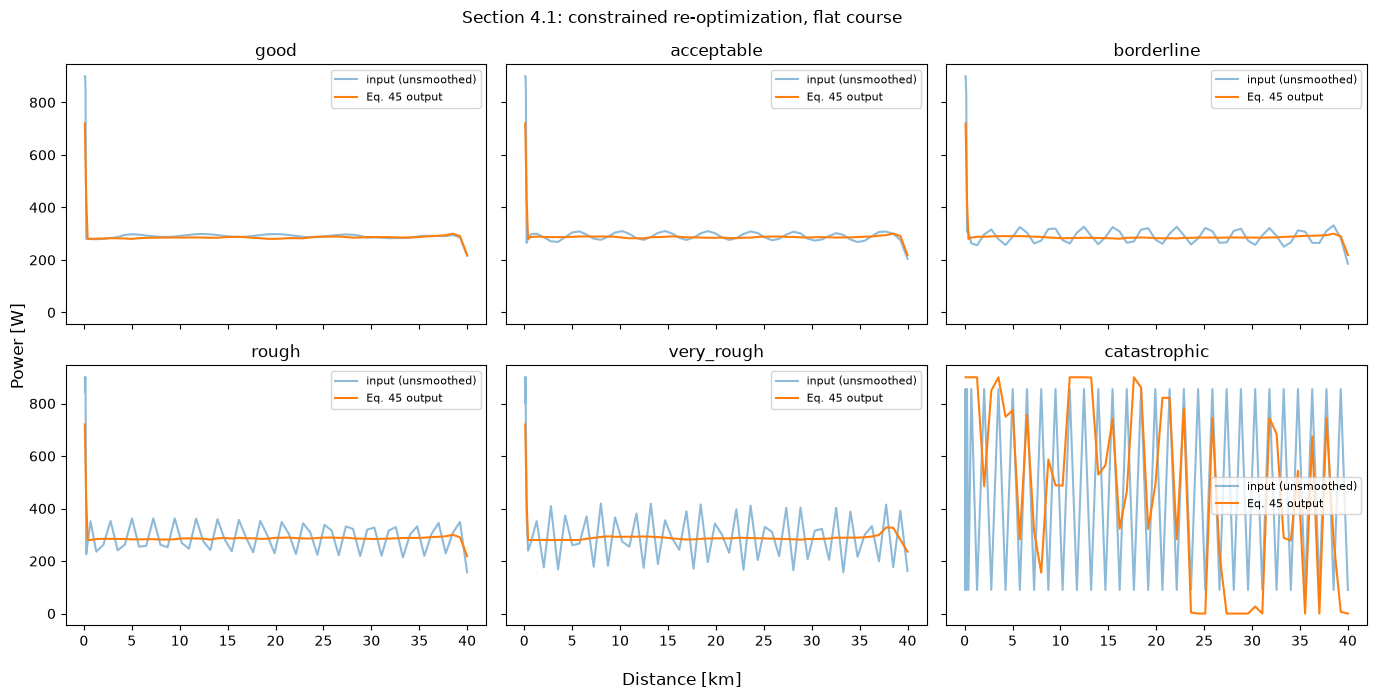

In [5]:
pc.plot_constrained_tiers(res_hs_flat, constrained_results_flat, "Section 4.1: constrained re-optimization, flat course")

The five milder tiers behave as the section describes: each converges to a
plan whose maximum realized slew is clamped to exactly the 2.0 W/m bound,
and each re-optimized time is slightly *above* its (identical, since only
`power_W`/`p_mid_W` were perturbed) unsmoothed baseline, by about 0.4 s.
That is the expected direction -- adding a constraint cannot improve the
optimum -- and is what `test_smoothing_constrained_satisfies_slew_bound`
checks. The cost is a fraction of a second because their node-to-node
power differences at this mesh's bulk spacing were already near or under
the bound.

**The `catastrophic` tier is now a genuine failure, and it is the only
result in this notebook that moved the wrong way.** It reports
T = 29.1138 min against a 57.1178 min baseline -- half the time -- with a
realized slew of 1.0454 W/m, i.e. the slew bound is not even active. It
previously reported 57.1600 min, +2.53 s, clamped at the bound.

It is not a new pathology in the physics, and it is not the `v_mid`
escape valve that 4.4 and 4.5 document: **the solve does not converge**.
It returns `success=False`, "Iteration limit reached", and at the point it
returns, `v_mid` runs from -80.7 to +97.4 m/s, violating the same
`v_mid >= v_min` row that fixed the other courses. The midpoint term of
the Simpson quadrature contributes **-668 s**, which is what drags the
reported time below a node-consistent value of about 120 min.

Two things follow. First, this tier's number was never trustworthy: it
exhausted `maxiter` before issue #6 as well, and merely happened to stop
somewhere plausible; the reachable `ftol` from item 7.6 changes which
iterate SLSQP stops on, not whether it converged. Second, and more
usefully, **`smooth_constrained` reports `time_total_s` from a
non-converged solve, and `run_constrained_tiers` prints it without
printing `success`.** The flag says `False` here and nothing surfaces it.
The cross-check ledger's Sec 4.1 time-monotonicity row does catch it, and
is the only row of its kind -- it exists for the flat course alone.

### 4.2 Rolling course

Same 6 tiers, applied to the rolling course's own baseline
(`res_hs_rolling`). One change: `catastrophic_mode="sine"` here instead of
the flat course's square wave. A full-range square wave, tried first on
this course, made `smooth_constrained`'s SLSQP re-solve land on a point
whose realized slew was *under* the 2.0 W/m bound yet reported a time far
below the unsmoothed baseline.

That is now known to be the unbounded midpoint speed, bounded since issue
#6 item 7.4, so the original reason for preferring `"sine"` here has
largely been removed -- it is kept because the tier definitions are fixed
inputs to a comparison that spans five courses, not because the square
wave is still known to break this one. Section 4.1's square-wave
`catastrophic` tier does still fail on the flat course, but by
non-convergence rather than by that escape valve, so re-testing `"square"`
here would be worth doing rather than assuming either outcome.

In [6]:
constrained_results_rolling = pc.run_constrained_tiers(opt_hs_rolling, res_hs_rolling, catastrophic_mode="sine", label="rolling")

[rolling] good         input |dP/ds|: p95=  0.292 max=    8.78 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=34.0803 min (unsmoothed 34.0745 min)   delta= +0.351 s


[rolling] acceptable   input |dP/ds|: p95=  0.376 max=    8.75 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=34.0803 min (unsmoothed 34.0745 min)   delta= +0.351 s


[rolling] borderline   input |dP/ds|: p95=  0.404 max=    8.11 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=34.0804 min (unsmoothed 34.0745 min)   delta= +0.352 s


[rolling] rough        input |dP/ds|: p95=  1.438 max=    9.72 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=34.0811 min (unsmoothed 34.0745 min)   delta= +0.399 s


[rolling] very_rough   input |dP/ds|: p95=  3.990 max=   11.63 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=34.0804 min (unsmoothed 34.0745 min)   delta= +0.354 s


[rolling] catastrophic input |dP/ds|: p95=  3.559 max=   10.91 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=34.0811 min (unsmoothed 34.0745 min)   delta= +0.399 s


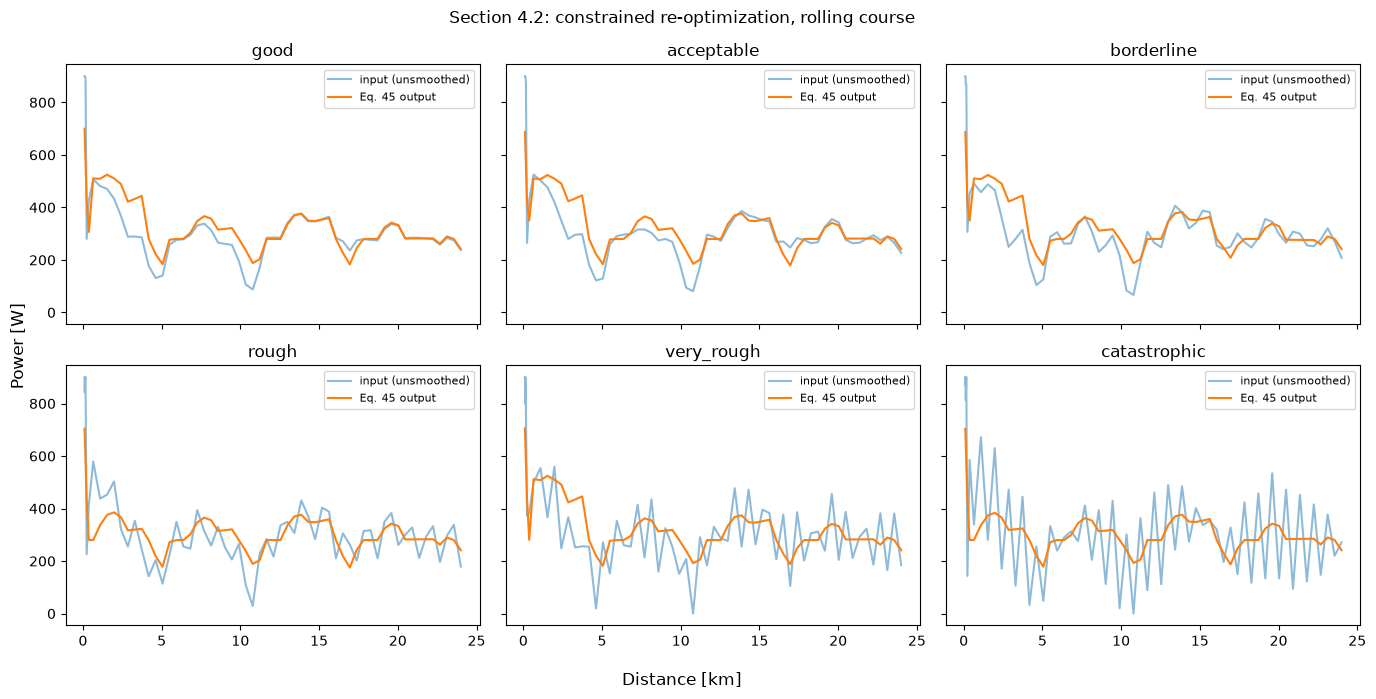

In [7]:
pc.plot_constrained_tiers(res_hs_rolling, constrained_results_rolling, "Section 4.2: constrained re-optimization, rolling course")

Every tier here now lands slightly *above* its unsmoothed baseline
(+0.35 to +0.40 s), which is the direction theory requires. This cell
previously documented the opposite -- "every tier here lands a few tenths
of a second *below* the unsmoothed baseline (roughly 0.04-0.06% of total
time)" -- and attributed it to solver precision. That reading was too
generous: the negative deltas came from the same unbounded midpoint speed
that produced this notebook's larger failures on TdF16 and TARA, and they
disappeared when `v_mid >= v_min` was added (issue #6 item 7.4).

The supporting claim it leaned on is also out of date. The rolling
course's baseline no longer reports `success=False`: that flag was
uninformative for every solve in the project until item 7.6 made SLSQP's
`ftol` reachable, and it now reports `True`.

### 4.3 Giro 2026 Stage 10 (real, flat)

Same 6 tiers as 4.1/4.2, on `opt_hs_giro10`/`res_hs_giro10` (rebuilt
above).

In [8]:
constrained_results_giro10 = pc.run_constrained_tiers(opt_hs_giro10, res_hs_giro10, catastrophic_mode="square", label="giro10")

[giro10] good         input |dP/ds|: p95=  0.289 max=   18.91 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=43.2793 min (unsmoothed 43.2630 min)   delta= +0.976 s


[giro10] acceptable   input |dP/ds|: p95=  0.306 max=   19.05 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=43.2886 min (unsmoothed 43.2630 min)   delta= +1.536 s


[giro10] borderline   input |dP/ds|: p95=  0.263 max=   19.87 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=43.2882 min (unsmoothed 43.2630 min)   delta= +1.513 s


[giro10] rough        input |dP/ds|: p95=  0.727 max=   17.19 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=43.2894 min (unsmoothed 43.2630 min)   delta= +1.585 s


[giro10] very_rough   input |dP/ds|: p95=  1.207 max=   14.62 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=43.2901 min (unsmoothed 43.2630 min)   delta= +1.624 s


[giro10] catastrophic input |dP/ds|: p95= 12.155 max=  185.22 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=43.2886 min (unsmoothed 43.2630 min)   delta= +1.536 s


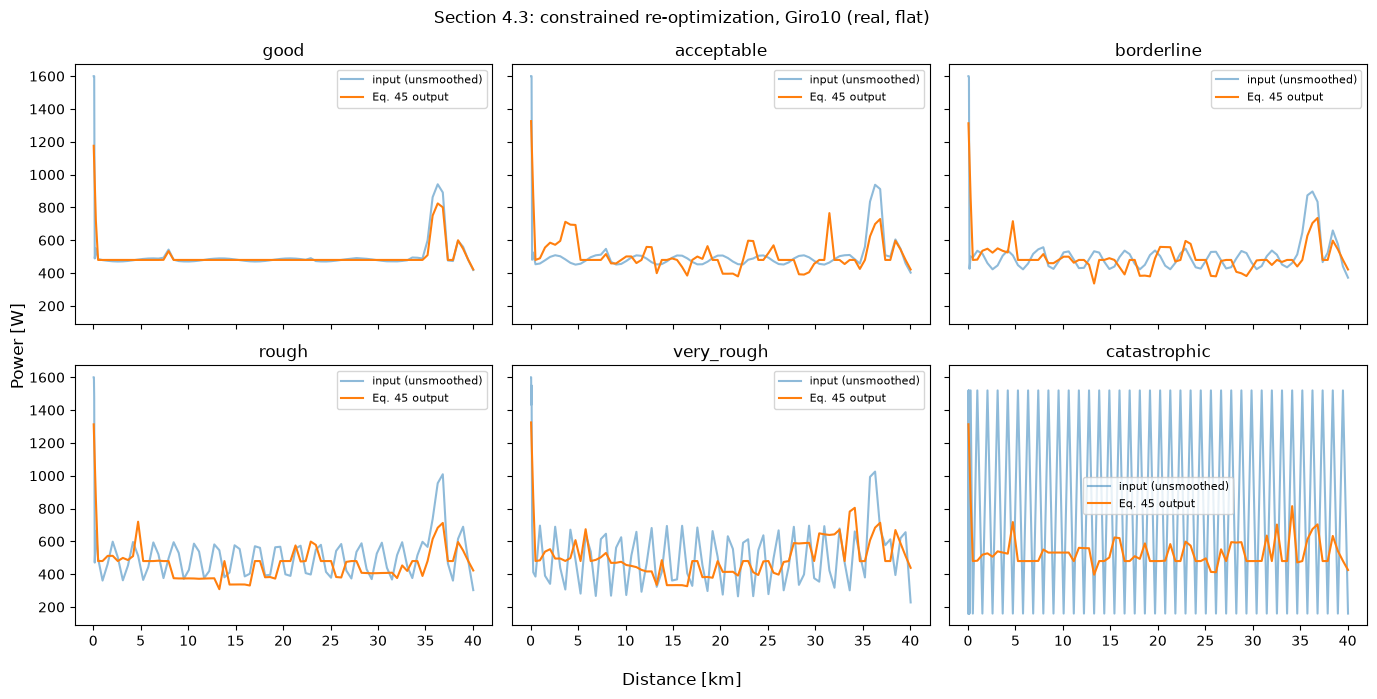

In [9]:
pc.plot_constrained_tiers(res_hs_giro10, constrained_results_giro10, "Section 4.3: constrained re-optimization, Giro10 (real, flat)")

Every tier here lands *above* its unsmoothed baseline (+0.98 to +1.62 s
out of a ~2596 s course), with the realized slew clamped to exactly the
2.0 W/m bound. This cell previously reported the opposite sign (-0.22 to
-0.55 s) and explained it as a course-agnostic solver-precision effect;
like 4.2's version of the same claim, it was the unbounded midpoint speed
(issue #6 item 7.4), and the deltas turned positive once that was bounded.

### 4.4 TdF 2026 Stage 16 (real, mountainous)

Same 6 tiers, on `opt_hs_tdf16`/`res_hs_tdf16` (rebuilt above) -- the
steepest terrain this smoothing demonstration sees. This subsection uses
`catastrophic_mode="sine"` below, but as its closing note shows, the
failure here is not a mode artifact -- both choices break down on this
course.

In [10]:
constrained_results_tdf16 = pc.run_constrained_tiers(opt_hs_tdf16, res_hs_tdf16, catastrophic_mode="sine", label="tdf16")

[tdf16] good         input |dP/ds|: p95=  0.559 max=   22.10 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=32.2523 min (unsmoothed 32.2492 min)   delta= +0.182 s


[tdf16] acceptable   input |dP/ds|: p95=  0.619 max=   22.16 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=32.2523 min (unsmoothed 32.2492 min)   delta= +0.182 s


[tdf16] borderline   input |dP/ds|: p95=  0.751 max=   20.62 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=32.2523 min (unsmoothed 32.2492 min)   delta= +0.183 s


[tdf16] rough        input |dP/ds|: p95=  1.333 max=   23.96 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=32.2523 min (unsmoothed 32.2492 min)   delta= +0.182 s


[tdf16] very_rough   input |dP/ds|: p95=  8.607 max=   27.76 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=32.2523 min (unsmoothed 32.2492 min)   delta= +0.182 s


[tdf16] catastrophic input |dP/ds|: p95=  8.495 max=   26.82 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=32.2523 min (unsmoothed 32.2492 min)   delta= +0.182 s


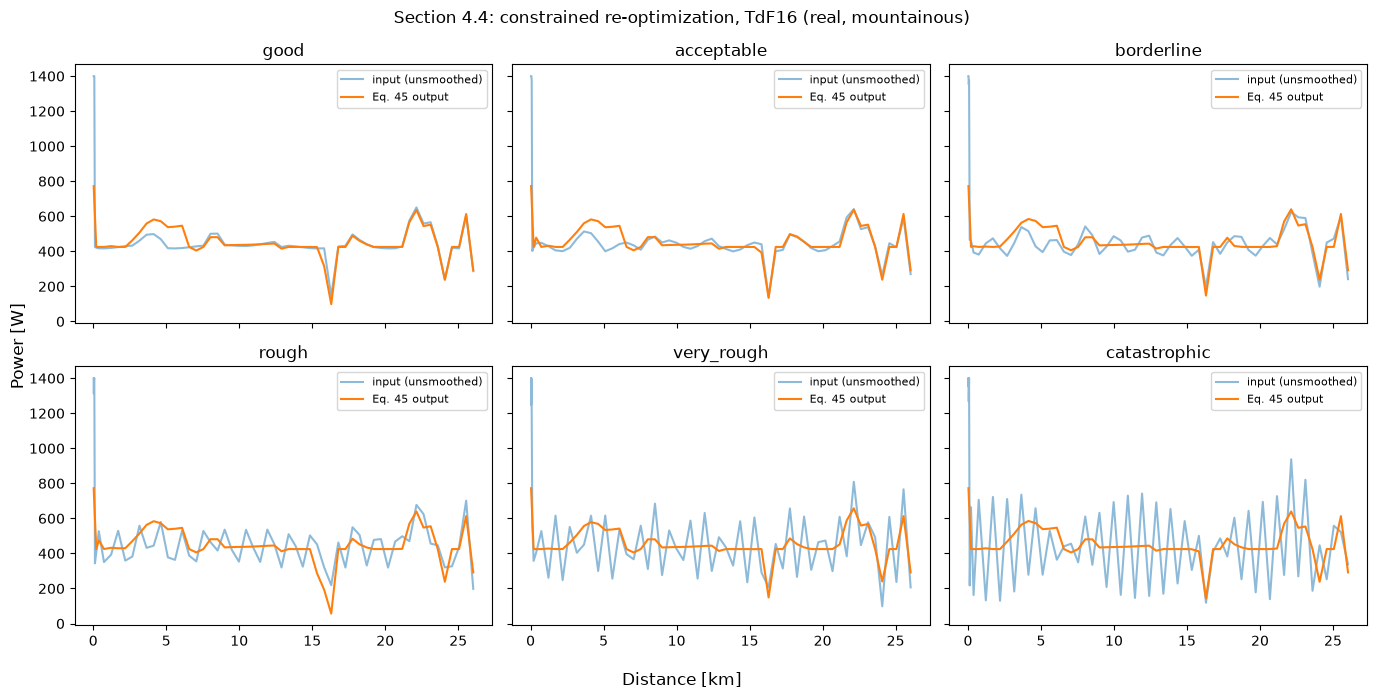

In [11]:
pc.plot_constrained_tiers(res_hs_tdf16, constrained_results_tdf16, "Section 4.4: constrained re-optimization, TdF16 (real, mountainous)")

**Both failures this subsection used to document are gone.** It previously
read that TdF16 was "the one course in this notebook where
`smooth_constrained`'s re-solve fails outright, on *two* tiers": the
`very_rough` tier reported T = 28.81 min, nearly 20% below the unsmoothed
37.19 min baseline, and the `catastrophic` tier reported a **negative**
time, -67.17 min.

Every tier now returns +0.182 s against a 32.2492 min baseline, with the
realized slew clamped to exactly 2.0 W/m. The fix is issue #6 item 7.4.
`v_mid` (design-doc Eq. 41) is a *derived* quantity: it carries no box
bound, and it enters the objective as `4 / v_mid`, so on a wide interval
the `(ds/8) * delta(dv/ds)` term could drive it through zero while both
node speeds stayed inside their bounds. A negative `v_mid` contributes a
negative term to a sum of times, which is exactly how a finish time goes
negative. Adding `v_mid >= v_min` as an inequality row, alongside the
`w_mid >= 0` row that already existed, closes it.

The lesson the subsection drew is still worth keeping, though it now has
to be drawn from elsewhere: a reported `time_total_s` is not
self-validating, and the launch-mesh notebook shows a graded-vs-uniform
pair where both solves report `success=True` and one is nonsense. Section
4.1 also has a live example on this page.

### 4.5 TARA 2026 Stage 3 (real, rolling/TTT)

Same 6 tiers, on `opt_hs_tara`/`res_hs_tara` (rebuilt above). Following
4.2's finding on the synthetic rolling course, this subsection uses
`catastrophic_mode="sine"` directly rather than re-discovering the same
square-wave pathology on real rolling terrain -- though, as the closing
note below shows, sine reduces but does not fully eliminate a similar
failure here.

In [12]:
constrained_results_tara = pc.run_constrained_tiers(opt_hs_tara, res_hs_tara, catastrophic_mode="sine", label="tara")

[tara] good         input |dP/ds|: p95=  0.635 max=   93.78 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=42.8523 min (unsmoothed 42.8427 min)   delta= +0.576 s


[tara] acceptable   input |dP/ds|: p95=  0.603 max=   91.91 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=42.8523 min (unsmoothed 42.8427 min)   delta= +0.578 s


[tara] borderline   input |dP/ds|: p95=  0.724 max=   88.27 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=42.8523 min (unsmoothed 42.8427 min)   delta= +0.576 s


[tara] rough        input |dP/ds|: p95=  1.348 max=   80.13 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=42.8523 min (unsmoothed 42.8427 min)   delta= +0.576 s


[tara] very_rough   input |dP/ds|: p95=  2.580 max=   71.30 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=42.8523 min (unsmoothed 42.8427 min)   delta= +0.576 s


[tara] catastrophic input |dP/ds|: p95=  2.220 max=   70.00 W/m  ->  output max |dP/ds|=2.0000 W/m (bound 2.0)   T=42.8523 min (unsmoothed 42.8427 min)   delta= +0.575 s


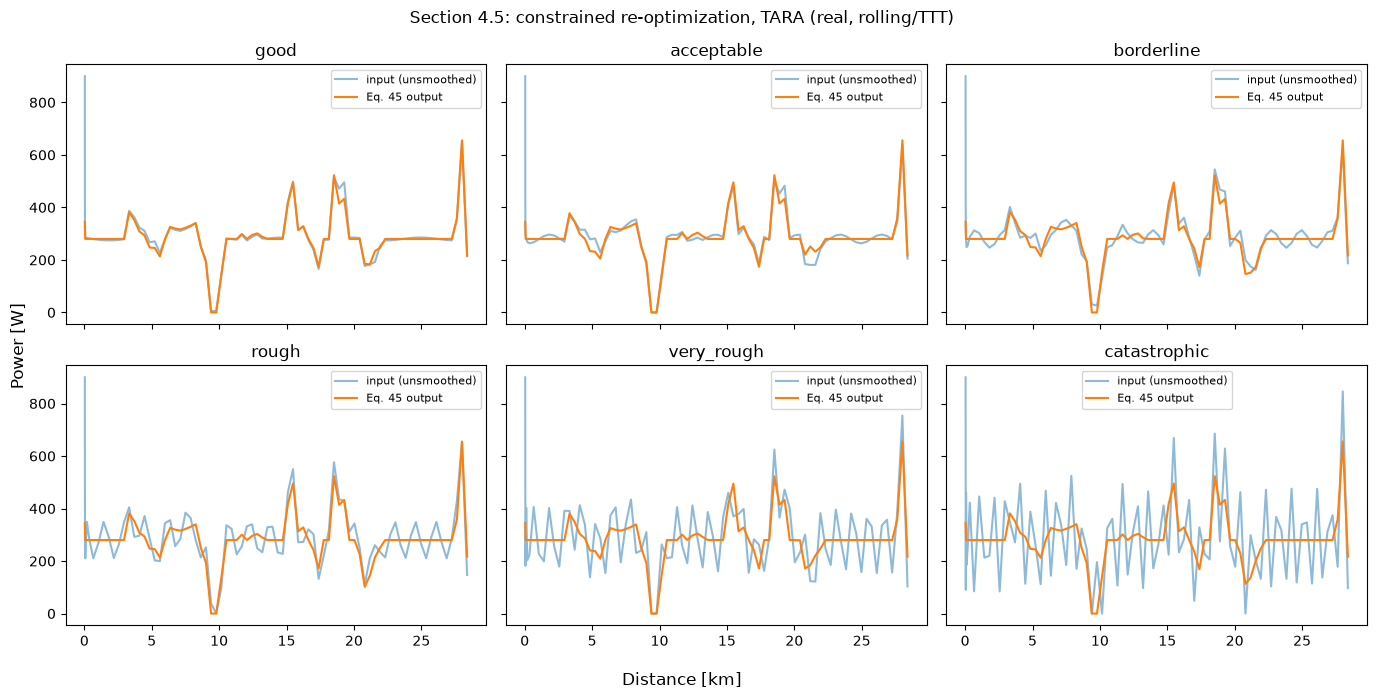

In [13]:
pc.plot_constrained_tiers(res_hs_tara, constrained_results_tara, "Section 4.5: constrained re-optimization, TARA (real, rolling/TTT)")

**TARA's two failures are gone as well**, including the one the cross-check
ledger used to list as a genuine gate failure. This subsection previously
reported that the *mildest* tier, `good`, came back at T = 32.52 min,
777.8 s (over 17%) faster than its 45.48 min baseline, and that
`catastrophic` could not bring the realized slew under the bound
(5.71 W/m against 2.0).

All six tiers now land at +0.575 to +0.578 s against a 42.8427 min
baseline, every one of them clamped to exactly 2.0 W/m. Same cause and
same fix as 4.4: the unbounded midpoint speed, closed by issue #6 item
7.4. The old "perturbation severity does not predict failure" puzzle
dissolves with it -- severity was never the variable, the escape valve
was, and which warm start happened to find it was arbitrary.

The wider claim this cell made about TARA being "genuinely harder for
this solver/mesh combination" also no longer holds in the form it was
written. The backend cross-check on TARA went from 5.96% to 0.179% and
the baseline's SLSQP-vs-simulator agreement from 2.68% to 0.148%, which
is inside its 0.5% gate. Both moved because of the graded-mesh fix (item
7.1), not because of anything in this notebook. TARA is still the real
course with the largest residual cross-backend gap, but "sharply
divergent" is no longer an accurate description of it.